📁 Selecciona tu archivo PDF cuando aparezca el recuadro de subida...


Saving Documento sin título.pdf to Documento sin título (2).pdf
✅ 15 comentarios cargados exitosamente.
                                          Comentario  Sentimiento
0  Me encanta este celular porque tiene buena bat...            1
1                La pantalla del celular es muy mala            0
2             Excelente servicio y excelente calidad            1
3        No me gusto el producto porque llego dañado            0
4   La bateria dura mucho tiempo y funciona muy bien            1


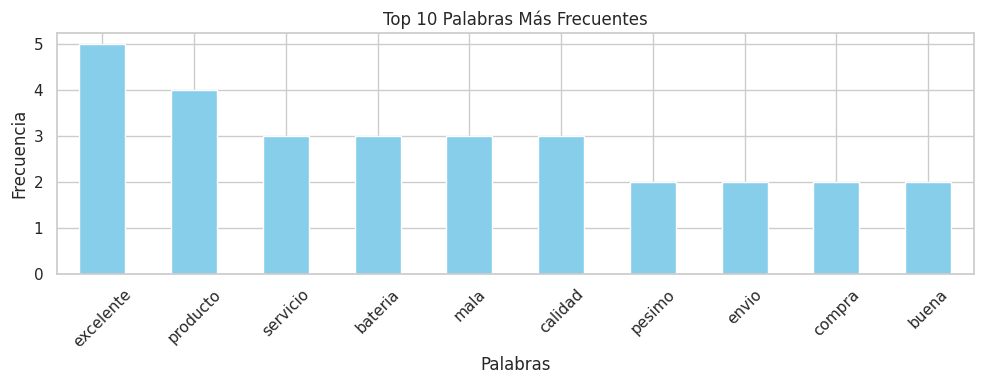

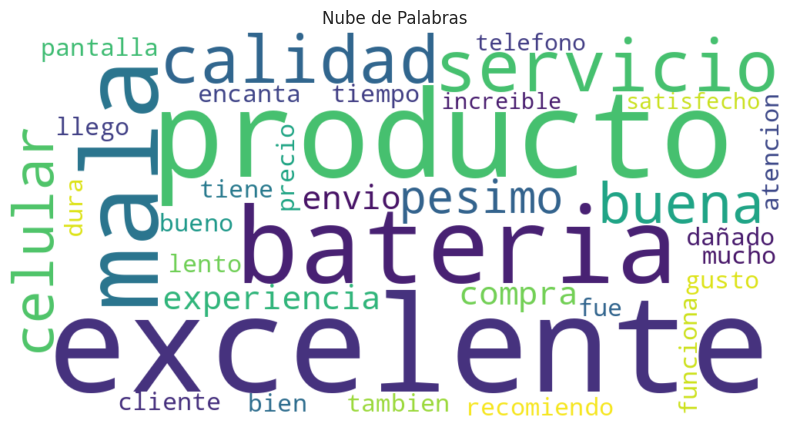


===== BIGRAMAS DETECTADOS =====
['atencion excelente', 'bateria dura', 'bateria telefono', 'buena bateria', 'buena experiencia', 'calidad excelente', 'celular mala', 'celular tiene', 'dura mucho', 'encanta celular', 'envio fue', 'envio mala', 'excelente atencion', 'excelente calidad', 'excelente precio', 'excelente producto', 'excelente servicio', 'experiencia compra', 'fue lento', 'funciona bien', 'gusto producto', 'lento producto', 'llego dañado', 'mala calidad', 'mala experiencia', 'mucho tiempo', 'pantalla celular', 'pesimo envio', 'pesimo servicio', 'precio tambien', 'producto bueno', 'producto llego', 'recomiendo producto', 'satisfecho servicio', 'servicio cliente', 'servicio excelente', 'telefono increible', 'tiempo funciona', 'tiene buena']


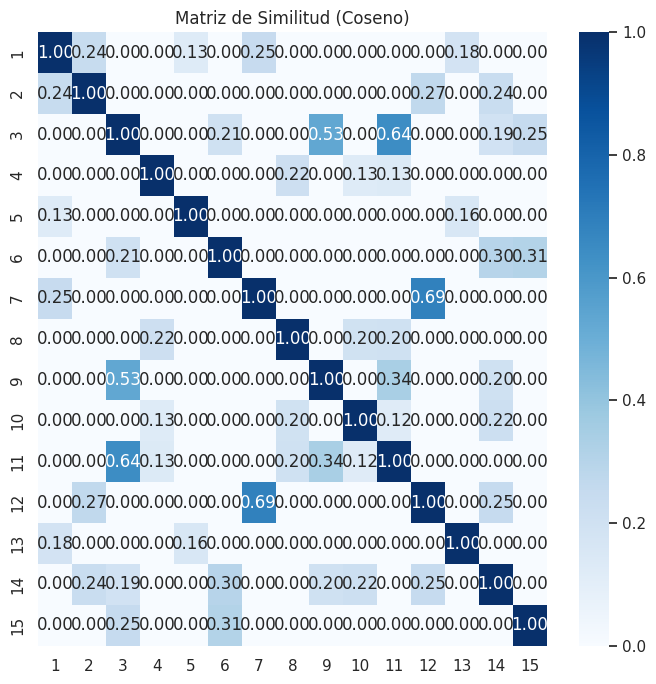


===== MÉTRICAS DEL MODELO =====
🎯 Accuracy: 0.6000

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

Negativo (0)       0.00      0.00      0.00         2
Positivo (1)       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



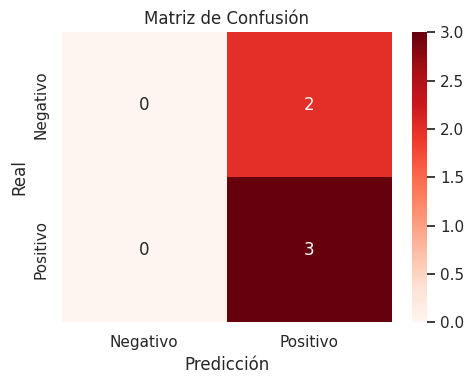


===== PREDICCIONES EN TEXTO NUEVO =====
📝 Excelente bateria y muy buen producto
🔮 Predicción: ✅ POSITIVO

📝 Pesimo servicio y mala calidad
🔮 Predicción: ❌ NEGATIVO



In [4]:

!pip install pdfplumber wordcloud seaborn scikit-learn matplotlib pandas numpy -q

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
from google.colab import files
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

sns.set(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})


def cargar_datos_desde_pdf(ruta_pdf):
    comentarios, sentimientos = [], []
    if not os.path.exists(ruta_pdf):
        raise FileNotFoundError(f"❌ No se encontró: {ruta_pdf}")

    with pdfplumber.open(ruta_pdf) as pdf:
        for pagina in pdf.pages:
            texto = pagina.extract_text()
            if not texto: continue
            for linea in texto.split('\n'):
                linea = linea.strip()
                if not linea: continue

                # Detecta separador: |, tab o coma
                sep = '|' if '|' in linea else '\t' if '\t' in linea else ',' if ',' in linea else None
                if not sep: continue

                partes = linea.split(sep)
                if len(partes) >= 2:
                    txt = partes[0].strip()
                    lbl = partes[1].strip().replace('\r', '')
                    if lbl in ['0', '1']:
                        comentarios.append(txt)
                        sentimientos.append(int(lbl))

    if not comentarios:
        raise ValueError("⚠️ No se encontraron datos válidos. Formato esperado por línea: 'Comentario | 0' o 'Comentario | 1'")
    return comentarios, sentimientos


print("📁 Selecciona tu archivo PDF cuando aparezca el recuadro de subida...")
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("❌ No se subió ningún archivo. Ejecuta la celda nuevamente y selecciona tu PDF.")

ruta_pdf = list(uploaded.keys())[0]
comentarios, sentimientos = cargar_datos_desde_pdf(ruta_pdf)
df = pd.DataFrame({"Comentario": comentarios, "Sentimiento": sentimientos})
print(f"✅ {len(df)} comentarios cargados exitosamente.")
print(df.head())

def limpiar_texto(t):
    t = t.lower()
    t = re.sub(r'[^a-záéíóúñ\s]', '', t)
    return t.strip()

df["Texto_Limpio"] = df["Comentario"].apply(limpiar_texto)
df["Tokens"] = df["Texto_Limpio"].apply(lambda x: x.split())

stopwords_es = [
    "el", "la", "los", "las", "de", "y", "a", "que", "porque", "muy", "pero",
    "al", "me", "no", "es", "este", "con", "un", "una", "para", "por", "en",
    "su", "se", "del", "como", "mas", "esta", "lo", "le", "les"
]


bow = CountVectorizer(stop_words=stopwords_es)
X_bow = bow.fit_transform(df["Texto_Limpio"])
frecuencias = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out()).sum().sort_values(ascending=False)

frecuencias.head(10).plot(kind="bar", figsize=(10,4), color="skyblue")
plt.title("Top 10 Palabras Más Frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


texto_total = " ".join(df["Texto_Limpio"])
wc = WordCloud(width=1000, height=500, background_color="white", stopwords=set(stopwords_es), colormap="viridis").generate(texto_total)
plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Nube de Palabras")
plt.show()

ngram_vec = CountVectorizer(stop_words=stopwords_es, ngram_range=(2,2))
X_ngram = ngram_vec.fit_transform(df["Texto_Limpio"])
print("\n===== BIGRAMAS DETECTADOS =====")
print(list(ngram_vec.get_feature_names_out()))

tfidf = TfidfVectorizer(stop_words=stopwords_es)
X_tfidf = tfidf.fit_transform(df["Texto_Limpio"])

sim = cosine_similarity(X_tfidf)
plt.figure(figsize=(max(6, len(sim)//2), max(6, len(sim)//2)))
sns.heatmap(sim, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=range(1, len(sim)+1), yticklabels=range(1, len(sim)+1))
plt.title("Matriz de Similitud (Coseno)")
plt.tight_layout()
plt.show()

X, y = X_tfidf, df["Sentimiento"]
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
except ValueError:
    # Fallback si solo hay una clase en el dataset pequeño
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = MultinomialNB()
modelo.fit(X_train, y_train)
preds = modelo.predict(X_test)

print("\n===== MÉTRICAS DEL MODELO =====")
print(f"🎯 Accuracy: {accuracy_score(y_test, preds):.4f}")
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, preds, zero_division=0, target_names=["Negativo (0)", "Positivo (1)"]))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

nuevos = [
    "Excelente bateria y muy buen producto",
    "Pesimo servicio y mala calidad"
]
nuevos_limpios = [limpiar_texto(t) for t in nuevos]
nuevos_vec = tfidf.transform(nuevos_limpios)
resultados = modelo.predict(nuevos_vec)

print("\n===== PREDICCIONES EN TEXTO NUEVO =====")
for texto, res in zip(nuevos, resultados):
    etiqueta = "✅ POSITIVO" if res == 1 else "❌ NEGATIVO"
    print(f"📝 {texto}")
    print(f"🔮 Predicción: {etiqueta}\n")